# Dataset 3: UNSW-NB15 Exploration (Phase 12)

**Goal:** UNSW-NB15 is a highly respected dataset created by the Australian Centre for Cyber Security. 
It is much more modern than NSL-KDD and contains complex, contemporary attacks like *Fuzzers*, *Worms*, and *Reconnaissance*. 

In this notebook, we will load the data, analyze the new attack types, and introduce a powerful mathematical concept called **Earth Mover's Distance (EMD)**.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance

plt.style.use('ggplot')

### Step 1: Loading the Official Splits (Subphase 12.1)
The creators of UNSW-NB15 were kind enough to provide an official `training-set.csv` and `testing-set.csv`. 
We will load the training set to explore the data.

In [7]:
# Load the official training set
file_path = "../data/raw/unsw-nb15/UNSW_NB15_training-set.csv"
df = pd.read_csv(file_path)

print(f"SUCCESS! Loaded {len(df):,} rows.")
print("\nFirst 5 rows:")
df.head()

SUCCESS! Loaded 82,332 rows.

First 5 rows:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


### Step 2: Modern Attack Categories (Subphase 12.2)
Unlike previous datasets, UNSW-NB15 uses a column called `attack_cat` for the specific attack name, and `label` (0 or 1) for normal vs attack.
Let's see what kind of modern attacks are in this dataset.

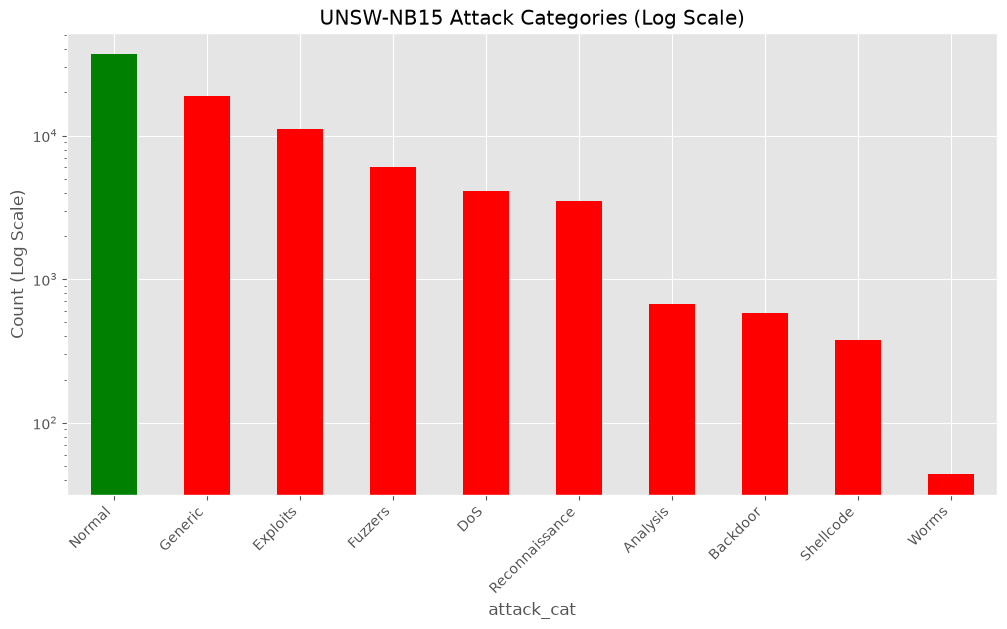

In [8]:
# Count the attack categories
attack_counts = df['attack_cat'].value_counts()

# Plot them (Log scale again, because 'Normal' is very large!)
plt.figure(figsize=(12, 6))
colors = ['green' if cat == 'Normal' else 'red' for cat in attack_counts.index]
attack_counts.plot(kind='bar', color=colors)

plt.yscale('log')
plt.title("UNSW-NB15 Attack Categories (Log Scale)")
plt.ylabel("Count (Log Scale)")
plt.xticks(rotation=45, ha='right')
plt.show()

### Step 3: Earth Mover's Distance (EMD) (Subphase 12.3)
**Earth Mover's Distance** (also called Wasserstein distance) is a famous mathematical formula. 
Imagine `Normal` traffic is a pile of dirt, and `Attack` traffic is a hole. The EMD score tells us how much 'work' it takes to move the dirt into the hole.

* **High EMD Score:** The feature looks completely different for attacks vs normal traffic (Very useful for AI!).
* **Low EMD Score:** The feature looks exactly the same for attacks and normal traffic (Useless for AI!).

Let's calculate the top 5 most powerful features using EMD!

Calculating Earth Mover's Distance for all features...


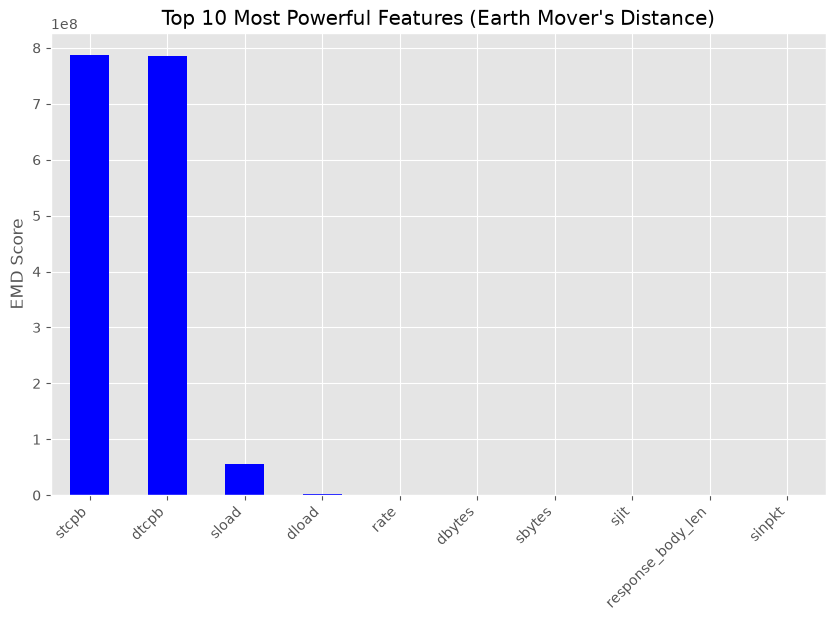

In [9]:
# 1. Split the data into Normal (label=0) and Attack (label=1)
normal_data = df[df['label'] == 0]
attack_data = df[df['label'] == 1]

# 2. Get only numeric columns to do the math
numeric_cols = df.select_dtypes(include=['number']).columns
numeric_cols = numeric_cols.drop(['id', 'label']) # Don't calculate EMD for the ID or Label column!

# 3. Calculate EMD for every feature
emd_scores = {}
print("Calculating Earth Mover's Distance for all features...")
for col in numeric_cols:
    score = wasserstein_distance(normal_data[col], attack_data[col])
    emd_scores[col] = score

# 4. Sort and plot the Top 10
emd_series = pd.Series(emd_scores).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
emd_series.head(10).plot(kind='bar', color='blue')
plt.title("Top 10 Most Powerful Features (Earth Mover's Distance)")
plt.ylabel("EMD Score")
plt.xticks(rotation=45, ha='right')
plt.show()

---
### Step 3b: Near-Zero Variance (Subphase 12.3)
If a feature has the exact same value for almost every single row, it has **Near-Zero Variance**. 
These features are basically useless because they don't help the AI distinguish between normal traffic and an attack. Let's find them so we can delete them later!

In [10]:
# 1. Calculate the mathematical variance of all numeric columns
variances = df.select_dtypes(include=['number']).var()

# 2. Find any feature where the variance is dangerously close to 0
near_zero = variances[variances < 0.01]

print(f"SUCCESS! Found {len(near_zero)} features with Near-Zero Variance.")
print("\nThese are candidates for deletion in the cleaning phase:")
print(near_zero)

SUCCESS! Found 4 features with Near-Zero Variance.

These are candidates for deletion in the cleaning phase:
synack          0.005020
ackdat          0.003035
is_ftp_login    0.008312
ct_ftp_cmd      0.008553
dtype: float64


---
### Step 4: EDA Findings & Conclusion
Here is the official **Action Plan** for UNSW-NB15:

1. **Cross-Dataset Schema Issue (Subphase 12.4):** 
   * UNSW-NB15 calls attacks `attack_cat`. 
   * NSL-KDD calls attacks `label`.
   * CICIDS-2017 calls attacks `Label`.
   * **Action:** Before we train a universal AI, we must map all these different names into a single **Unified Schema** (e.g., standardizing everything to `unified_label`).
2. **Rare Attacks:** Attacks like `Worms` and `Shellcode` have very few examples.
   * **Action:** We must use SMOTE (oversampling) during training so the AI doesn't ignore these rare attacks.
3. **Feature Separability:** EMD proved that features like `sbytes` (Source to destination bytes) are incredibly powerful at separating normal traffic from attacks.